# AirSight — Final Integration

This notebook connects the final **Residual LSTM traffic forecasts** with the validated **Operational Pressure** thresholds.

**Final flow**

`3-hour traffic forecast → Operational Pressure → Pressure Evaluation → Operational Context → Recommendation`


## 1. Setup

The notebook uses:
- final Residual LSTM predictions from the test period,
- the traffic-only model-ready dataset for historical context,
- the validated pressure thresholds from the operational-pressure analysis.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

PREDICTIONS_PATH = "/content/drive/MyDrive/AirSight/final_lstm_predictions.csv"
TRAFFIC_PATH = "/content/drive/MyDrive/AirSight/model_ready_traffic.csv"

PRESSURE_ORDER = ["Normal", "High", "Extreme"]

## 2. Load Final Model Outputs

`final_lstm_predictions.csv` contains the final Residual LSTM predictions averaged across the model seeds.

The model output remains continuous for forecasting metrics. For the pressure layer, predicted movements are rounded to the nearest whole movement because airport movements are count data.

In [3]:
predictions = pd.read_csv(PREDICTIONS_PATH, parse_dates=["hour"])
traffic = (
    pd.read_csv(TRAFFIC_PATH, parse_dates=["hour"])
    .sort_values("hour")
    .reset_index(drop=True)
)

required_cols = [
    "hour",
    "actual_t1", "pred_t1",
    "actual_t2", "pred_t2",
    "actual_t3", "pred_t3",
]

missing = [col for col in required_cols if col not in predictions.columns]
if missing:
    raise ValueError(f"Missing columns in predictions file: {missing}")

predictions = predictions.sort_values("hour").reset_index(drop=True)

print("Prediction rows:", len(predictions))
print("Test period:", predictions["hour"].min(), "to", predictions["hour"].max())
display(predictions.head())

Prediction rows: 729
Test period: 2025-09-09 21:00:00+00:00 to 2025-10-10 05:00:00+00:00


,hour,actual_t1,actual_t2,actual_t3,pred_t1,pred_t2,pred_t3
0,2025-09-09 21:00:00+00:00,24.0,27.0,18.0,22.893766,26.001053,17.255733
1,2025-09-09 22:00:00+00:00,27.0,18.0,15.0,26.446731,17.322645,15.438047
2,2025-09-09 23:00:00+00:00,18.0,15.0,22.0,18.027279,15.930177,21.835228
3,2025-09-10 00:00:00+00:00,15.0,22.0,31.0,16.180906,22.043500,30.957864
4,2025-09-10 01:00:00+00:00,22.0,31.0,32.0,22.069848,30.802152,31.808781


## 3. Apply Operational Pressure Thresholds

The final thresholds were derived from the historical operational-pressure analysis and refined using the validation period:

- **Normal:** 21 or fewer movements/hour
- **High:** 22–34 movements/hour
- **Extreme:** 35 or more movements/hour

These levels are an **operational pressure proxy**, not a direct airport-capacity or congestion measure.

In [4]:
def pressure_level(movements):
    if movements <= 21:
        return "Normal"
    if movements <= 34:
        return "High"
    return "Extreme"


for h in range(1, 4):
    predictions[f"pred_count_t{h}"] = np.rint(predictions[f"pred_t{h}"]).astype(int)
    predictions[f"actual_pressure_t{h}"] = predictions[f"actual_t{h}"].apply(pressure_level)
    predictions[f"pred_pressure_t{h}"] = predictions[f"pred_count_t{h}"].apply(pressure_level)

display(
    predictions[
        [
            "hour",
            "actual_t1", "pred_t1", "pred_count_t1",
            "actual_pressure_t1", "pred_pressure_t1",
        ]
    ].head()
)

,hour,actual_t1,pred_t1,pred_count_t1,actual_pressure_t1,pred_pressure_t1
0,2025-09-09 21:00:00+00:00,24.0,22.893766,23,High,High
1,2025-09-09 22:00:00+00:00,27.0,26.446731,26,High,High
2,2025-09-09 23:00:00+00:00,18.0,18.027279,18,Normal,Normal
3,2025-09-10 00:00:00+00:00,15.0,16.180906,16,Normal,Normal
4,2025-09-10 01:00:00+00:00,22.0,22.069848,22,High,High


## 4. End-to-End Pressure Evaluation

Forecasting metrics measure how close the predicted movement count is to the actual count.

This section evaluates the **final decision-support output** instead: whether the predicted traffic leads to the correct pressure level.

Reported metrics:
- **Pressure Accuracy:** exact Normal / High / Extreme match.
- **Macro F1:** gives equal importance to all three pressure levels.
- **High-Pressure Detection Rate:** share of actual High or Extreme periods detected as High or Extreme.
- **Caught / Missed / False Alarms:** an operational view of how well High/Extreme periods are identified.

In [5]:
def evaluate_pressure(actual, predicted, horizon):
    accuracy = accuracy_score(actual, predicted)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        actual,
        predicted,
        labels=PRESSURE_ORDER,
        average="macro",
        zero_division=0,
    )

    actual_high = actual.isin(["High", "Extreme"])
    predicted_high = predicted.isin(["High", "Extreme"])

    caught = (actual_high & predicted_high).sum()
    missed = (actual_high & ~predicted_high).sum()
    false_alarms = (~actual_high & predicted_high).sum()

    high_detection = caught / actual_high.sum() if actual_high.sum() > 0 else np.nan

    return {
        "Horizon": horizon,
        "Pressure Accuracy": accuracy,
        "Macro F1": macro_f1,
        "High-Pressure Detection Rate": high_detection,
        "Caught": int(caught),
        "Missed": int(missed),
        "False Alarms": int(false_alarms),
    }


pressure_results = []

for h in range(1, 4):
    pressure_results.append(
        evaluate_pressure(
            predictions[f"actual_pressure_t{h}"],
            predictions[f"pred_pressure_t{h}"],
            f"t+{h}",
        )
    )

pressure_results = pd.DataFrame(pressure_results)

display(
    pressure_results.style.format(
        {
            "Pressure Accuracy": "{:.1%}",
            "Macro F1": "{:.3f}",
            "High-Pressure Detection Rate": "{:.1%}",
        }
    )
)

,Horizon,Pressure Accuracy,Macro F1,High-Pressure Detection Rate,Caught,Missed,False Alarms
0,t+1,90.9%,0.903,98.6%,629,9,12
1,t+2,90.3%,0.896,98.3%,627,11,12
2,t+3,90.5%,0.902,98.9%,631,7,12


### Confusion Matrices

The confusion matrices show which pressure levels are confused and whether errors remain between adjacent levels or cross the Normal vs High/Extreme boundary.

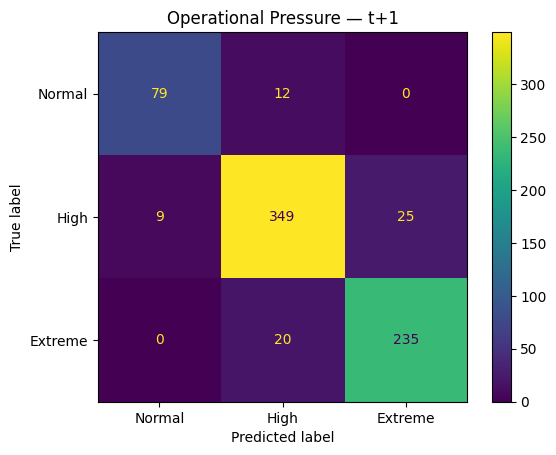

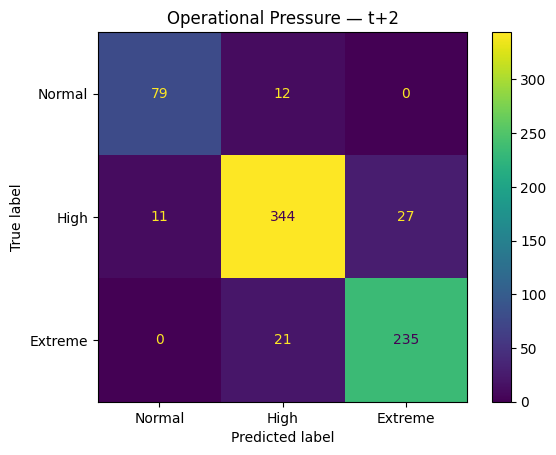

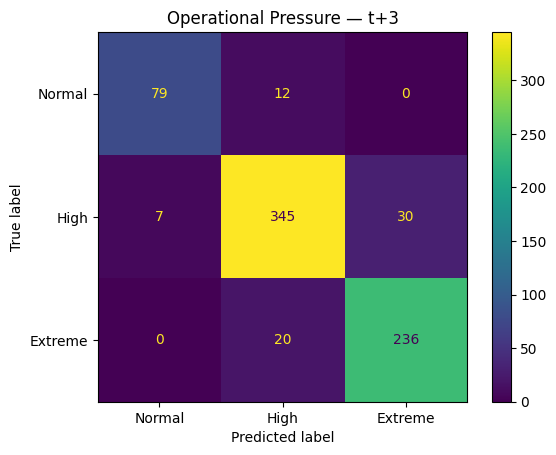

In [6]:
for h in range(1, 4):
    cm = confusion_matrix(
        predictions[f"actual_pressure_t{h}"],
        predictions[f"pred_pressure_t{h}"],
        labels=PRESSURE_ORDER,
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=PRESSURE_ORDER,
    )
    disp.plot()
    plt.title(f"Operational Pressure — t+{h}")
    plt.show()

## 5. Historical Traffic Context

A fixed movement count does not have the same meaning at every hour of the week.

To add context, the expected traffic level for each Riyadh **day-of-week × hour-of-day** combination is learned from the training period only. The forecast can then be compared with the typical activity for its target time.

This context supports interpretation; it does not replace the pressure thresholds.

In [7]:
HORIZON = 3

n = len(traffic)
train_end = int(n * 0.70)
train = traffic.iloc[: train_end - HORIZON].copy()

train_local = train["hour"].dt.tz_convert("Asia/Riyadh")
train["hour_of_day_context"] = train_local.dt.hour
train["day_of_week_context"] = train_local.dt.dayofweek

traffic_baseline = (
    train.groupby(["day_of_week_context", "hour_of_day_context"])["flight_count"]
    .agg(expected_traffic="mean", traffic_std="std")
    .reset_index()
)

traffic_baseline.head()

,day_of_week_context,hour_of_day_context,expected_traffic,traffic_std
0,0,0,12.10,8.849026
1,0,1,14.15,6.217759
2,0,2,20.30,1.838191
3,0,3,17.55,2.012461
4,0,4,16.85,2.230766


In [8]:
context_frames = []

for h in range(1, 4):
    frame = predictions[
        [
            "hour",
            f"actual_t{h}",
            f"pred_t{h}",
            f"pred_count_t{h}",
            f"actual_pressure_t{h}",
            f"pred_pressure_t{h}",
        ]
    ].copy()

    frame["horizon"] = f"t+{h}"
    frame["target_hour"] = frame["hour"] + pd.Timedelta(hours=h)

    # Use Riyadh local time for the historical context
    local_target = frame["target_hour"].dt.tz_convert("Asia/Riyadh")
    frame["target_hour_local"] = local_target
    frame["hour_of_day_context"] = local_target.dt.hour
    frame["day_of_week_context"] = local_target.dt.dayofweek

    frame = frame.merge(
        traffic_baseline,
        on=["day_of_week_context", "hour_of_day_context"],
        how="left",
    )

    # Difference from the expected traffic level
    frame["forecast_vs_expected"] = (
        frame[f"pred_t{h}"] - frame["expected_traffic"]
    )

    # Relative deviation from the normal variation for that hour/day
    frame["traffic_zscore"] = (
        frame["forecast_vs_expected"] / frame["traffic_std"]
    )

    frame = frame.rename(
        columns={
            f"actual_t{h}": "actual",
            f"pred_t{h}": "forecast",
            f"pred_count_t{h}": "forecast_movements",
            f"actual_pressure_t{h}": "actual_pressure",
            f"pred_pressure_t{h}": "predicted_pressure",
        }
    )

    context_frames.append(frame)

pressure_detail = pd.concat(context_frames, ignore_index=True)

display(
    pressure_detail[
        [
            "target_hour_local",
            "horizon",
            "forecast_movements",
            "predicted_pressure",
            "expected_traffic",
            "forecast_vs_expected",
            "traffic_zscore",
        ]
    ].head()
)

,target_hour_local,horizon,forecast_movements,predicted_pressure,expected_traffic,forecast_vs_expected,traffic_zscore
0,2025-09-10 01:00:00+03:00,t+1,23,High,23.05,-0.156234,-0.039256
1,2025-09-10 02:00:00+03:00,t+1,26,High,22.10,4.346731,1.537813
2,2025-09-10 03:00:00+03:00,t+1,18,Normal,18.10,-0.072721,-0.030530
3,2025-09-10 04:00:00+03:00,t+1,16,Normal,14.70,1.480906,0.557222
4,2025-09-10 05:00:00+03:00,t+1,22,High,22.60,-0.530152,-0.138398


In [9]:
def classify_traffic_context(z):
    if pd.isna(z):
        return "Historical context unavailable"

    if z > 1:
        return "Above typical"
    elif z < -1:
        return "Below typical"
    else:
        return "Typical"


pressure_detail["traffic_context"] = (
    pressure_detail["traffic_zscore"]
    .apply(classify_traffic_context)
)

display(
    pressure_detail[
        [
            "target_hour_local",
            "horizon",
            "forecast_movements",
            "predicted_pressure",
            "expected_traffic",
            "traffic_zscore",
            "traffic_context",
        ]
    ].head()
)

,target_hour_local,horizon,forecast_movements,predicted_pressure,expected_traffic,traffic_zscore,traffic_context
0,2025-09-10 01:00:00+03:00,t+1,23,High,23.05,-0.039256,Typical
1,2025-09-10 02:00:00+03:00,t+1,26,High,22.10,1.537813,Above typical
2,2025-09-10 03:00:00+03:00,t+1,18,Normal,18.10,-0.030530,Typical
3,2025-09-10 04:00:00+03:00,t+1,16,Normal,14.70,0.557222,Typical
4,2025-09-10 05:00:00+03:00,t+1,22,High,22.60,-0.138398,Typical


## 6. Recommendation Layer

The recommendation layer converts the forecast into decision-support prompts using:

- the predicted operational pressure level,
- the historical traffic context for the same Riyadh hour and day.

Recommendation themes focus on monitoring, operational readiness, passenger-processing awareness, ground operations, and cross-team coordination.

The system does not prescribe staffing levels, gate assignments, delays, or cancellations because these require live operational data outside the project scope.

In [10]:
def recommendation(pressure, traffic_context):
    if pressure == "Normal":
        return "Maintain standard operational monitoring."

    if pressure == "High":
        if traffic_context == "Above typical":
            return (
                "Increase operational monitoring and review readiness across "
                "passenger-processing and ground-operation areas."
            )
        return (
            "Increase operational monitoring and review operational readiness "
            "for the upcoming period."
        )

    # Extreme
    if traffic_context == "Above typical":
        return (
            "Prioritize cross-team coordination and closely monitor "
            "passenger-processing and ground-operation readiness."
        )

    return (
        "Prioritize operational coordination and maintain close monitoring "
        "during the upcoming peak period."
    )


pressure_detail["recommendation"] = pressure_detail.apply(
    lambda row: recommendation(
        row["predicted_pressure"],
        row["traffic_context"],
    ),
    axis=1,
)

display(
    pressure_detail[
        [
            "target_hour_local",
            "horizon",
            "forecast_movements",
            "predicted_pressure",
            "traffic_context",
            "recommendation",
        ]
    ].head(10)
)

,target_hour_local,horizon,forecast_movements,predicted_pressure,traffic_context,recommendation
0,2025-09-10 01:00:00+03:00,t+1,23,High,Typical,Increase operational monitoring and review ope...
1,2025-09-10 02:00:00+03:00,t+1,26,High,Above typical,Increase operational monitoring and review rea...
2,2025-09-10 03:00:00+03:00,t+1,18,Normal,Typical,Maintain standard operational monitoring.
3,2025-09-10 04:00:00+03:00,t+1,16,Normal,Typical,Maintain standard operational monitoring.
4,2025-09-10 05:00:00+03:00,t+1,22,High,Typical,Increase operational monitoring and review ope...
5,2025-09-10 06:00:00+03:00,t+1,31,High,Typical,Increase operational monitoring and review ope...
6,2025-09-10 07:00:00+03:00,t+1,32,High,Typical,Increase operational monitoring and review ope...
7,2025-09-10 08:00:00+03:00,t+1,32,High,Typical,Increase operational monitoring and review ope...
8,2025-09-10 09:00:00+03:00,t+1,33,High,Typical,Increase operational monitoring and review ope...
9,2025-09-10 10:00:00+03:00,t+1,33,High,Typical,Increase operational monitoring and review ope...


## 7. Final 3-Hour Operational Outlook

The final system view combines the three forecast horizons into one concise operational outlook.

For the interactive dashboard, all available test-set forecast origins are retained. Each forecast origin includes the t+1, t+2, and t+3 horizons together with the predicted traffic, operational pressure, historical traffic context, and readiness recommendation.

This allows the Streamlit interface to dynamically update the full dashboard based on the forecast start time selected by the user.

In [14]:
# Prepare dashboard-ready data for all available forecast origins
dashboard_data = pressure_detail[
    [
        "hour",
        "target_hour_local",
        "horizon",
        "forecast_movements",
        "predicted_pressure",
        "expected_traffic",
        "forecast_vs_expected",
        "traffic_zscore",
        "traffic_context",
        "recommendation",
    ]
].copy()

# Convert forecast start time to Riyadh local time for the dashboard
dashboard_data["forecast_origin_local"] = (
    dashboard_data["hour"].dt.tz_convert("Asia/Riyadh")
)

# Remove the original timestamp from the dashboard-facing dataset
dashboard_data = dashboard_data.drop(columns="hour")

# Reorder columns for clarity
dashboard_data = dashboard_data[
    [
        "forecast_origin_local",
        "target_hour_local",
        "horizon",
        "forecast_movements",
        "predicted_pressure",
        "expected_traffic",
        "forecast_vs_expected",
        "traffic_zscore",
        "traffic_context",
        "recommendation",
    ]
]

dashboard_data = (
    dashboard_data
    .sort_values(["forecast_origin_local", "horizon"])
    .reset_index(drop=True)
)

# Round display-oriented values
dashboard_data["expected_traffic"] = dashboard_data["expected_traffic"].round(1)
dashboard_data["forecast_vs_expected"] = dashboard_data["forecast_vs_expected"].round(1)
dashboard_data["traffic_zscore"] = dashboard_data["traffic_zscore"].round(2)

display(dashboard_data.head(12))

,forecast_origin_local,target_hour_local,horizon,forecast_movements,predicted_pressure,expected_traffic,forecast_vs_expected,traffic_zscore,traffic_context,recommendation
0,2025-09-10 00:00:00+03:00,2025-09-10 01:00:00+03:00,t+1,23,High,23.0,-0.2,-0.04,Typical,Increase operational monitoring and review ope...
1,2025-09-10 00:00:00+03:00,2025-09-10 02:00:00+03:00,t+2,26,High,22.1,3.9,1.38,Above typical,Increase operational monitoring and review rea...
2,2025-09-10 00:00:00+03:00,2025-09-10 03:00:00+03:00,t+3,17,Normal,18.1,-0.8,-0.35,Typical,Maintain standard operational monitoring.
3,2025-09-10 01:00:00+03:00,2025-09-10 02:00:00+03:00,t+1,26,High,22.1,4.3,1.54,Above typical,Increase operational monitoring and review rea...
4,2025-09-10 01:00:00+03:00,2025-09-10 03:00:00+03:00,t+2,17,Normal,18.1,-0.8,-0.33,Typical,Maintain standard operational monitoring.
5,2025-09-10 01:00:00+03:00,2025-09-10 04:00:00+03:00,t+3,15,Normal,14.7,0.7,0.28,Typical,Maintain standard operational monitoring.
6,2025-09-10 02:00:00+03:00,2025-09-10 03:00:00+03:00,t+1,18,Normal,18.1,-0.1,-0.03,Typical,Maintain standard operational monitoring.
7,2025-09-10 02:00:00+03:00,2025-09-10 04:00:00+03:00,t+2,16,Normal,14.7,1.2,0.46,Typical,Maintain standard operational monitoring.
8,2025-09-10 02:00:00+03:00,2025-09-10 05:00:00+03:00,t+3,22,High,22.6,-0.8,-0.20,Typical,Increase operational monitoring and review ope...
9,2025-09-10 03:00:00+03:00,2025-09-10 04:00:00+03:00,t+1,16,Normal,14.7,1.5,0.56,Typical,Maintain standard operational monitoring.


## 8. Export Dashboard-Ready Data

The full dashboard-ready dataset is exported for use in the Streamlit application.

It contains all available test-set forecast origins and the corresponding three-hour outlook for each origin, allowing the interface to update dynamically when a different forecast start time is selected.

In [15]:
# Export data used by the interactive dashboard
dashboard_data.to_csv(
    "airsight_dashboard_data.csv",
    index=False
)

# Export pressure evaluation results for reporting
pressure_results.to_csv(
    "airsight_pressure_evaluation.csv",
    index=False
)

print("Saved: airsight_dashboard_data.csv")
print("Saved: airsight_pressure_evaluation.csv")

Saved: airsight_dashboard_data.csv
Saved: airsight_pressure_evaluation.csv


## 9. Final Integration Summary

The final AirSight pipeline is:

**Residual LSTM → 3-hour traffic forecast → Operational Pressure → Historical Context → Readiness Recommendation → Interactive Dashboard**

The pressure levels remain a data-derived operational proxy. The system is designed to support early situational awareness, readiness, and operational planning, not to make automated capacity, staffing, gate, delay, or cancellation decisions.

The dashboard uses the prepared test-set forecasts to allow users to explore different forecast start times and view the corresponding three-hour operational outlook.

In [16]:
summary = pressure_results.copy()

summary["Pressure Accuracy"] = summary["Pressure Accuracy"].map(
    lambda x: f"{x:.1%}"
)
summary["Macro F1"] = summary["Macro F1"].map(
    lambda x: f"{x:.3f}"
)
summary["High-Pressure Detection Rate"] = summary[
    "High-Pressure Detection Rate"
].map(
    lambda x: f"{x:.1%}"
)

print("FINAL PRESSURE EVALUATION")
display(summary)

print("\nDASHBOARD-READY DATA SAMPLE")
display(dashboard_data.head(12))

FINAL PRESSURE EVALUATION


,Horizon,Pressure Accuracy,Macro F1,High-Pressure Detection Rate,Caught,Missed,False Alarms
0,t+1,90.9%,0.903,98.6%,629,9,12
1,t+2,90.3%,0.896,98.3%,627,11,12
2,t+3,90.5%,0.902,98.9%,631,7,12



DASHBOARD-READY DATA SAMPLE


,forecast_origin_local,target_hour_local,horizon,forecast_movements,predicted_pressure,expected_traffic,forecast_vs_expected,traffic_zscore,traffic_context,recommendation
0,2025-09-10 00:00:00+03:00,2025-09-10 01:00:00+03:00,t+1,23,High,23.0,-0.2,-0.04,Typical,Increase operational monitoring and review ope...
1,2025-09-10 00:00:00+03:00,2025-09-10 02:00:00+03:00,t+2,26,High,22.1,3.9,1.38,Above typical,Increase operational monitoring and review rea...
2,2025-09-10 00:00:00+03:00,2025-09-10 03:00:00+03:00,t+3,17,Normal,18.1,-0.8,-0.35,Typical,Maintain standard operational monitoring.
3,2025-09-10 01:00:00+03:00,2025-09-10 02:00:00+03:00,t+1,26,High,22.1,4.3,1.54,Above typical,Increase operational monitoring and review rea...
4,2025-09-10 01:00:00+03:00,2025-09-10 03:00:00+03:00,t+2,17,Normal,18.1,-0.8,-0.33,Typical,Maintain standard operational monitoring.
5,2025-09-10 01:00:00+03:00,2025-09-10 04:00:00+03:00,t+3,15,Normal,14.7,0.7,0.28,Typical,Maintain standard operational monitoring.
6,2025-09-10 02:00:00+03:00,2025-09-10 03:00:00+03:00,t+1,18,Normal,18.1,-0.1,-0.03,Typical,Maintain standard operational monitoring.
7,2025-09-10 02:00:00+03:00,2025-09-10 04:00:00+03:00,t+2,16,Normal,14.7,1.2,0.46,Typical,Maintain standard operational monitoring.
8,2025-09-10 02:00:00+03:00,2025-09-10 05:00:00+03:00,t+3,22,High,22.6,-0.8,-0.20,Typical,Increase operational monitoring and review ope...
9,2025-09-10 03:00:00+03:00,2025-09-10 04:00:00+03:00,t+1,16,Normal,14.7,1.5,0.56,Typical,Maintain standard operational monitoring.
